In [1]:
import importnb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

print('OK')

OK


Op_Setting_1    2.187313e-03
Op_Setting_2    2.930621e-04
Op_Setting_3    0.000000e+00
Sensor_1        0.000000e+00
Sensor_2        5.000533e-01
Sensor_3        6.131150e+00
Sensor_4        9.000605e+00
Sensor_5        5.329200e-15
Sensor_6        1.388985e-03
Sensor_7        8.850923e-01
Sensor_8        7.098548e-02
Sensor_9        2.208288e+01
Sensor_10       0.000000e+00
Sensor_11       2.670874e-01
Sensor_12       7.375534e-01
Sensor_13       7.191892e-02
Sensor_14       1.907618e+01
Sensor_15       3.750504e-02
Sensor_16       3.469531e-18
Sensor_17       1.548763e+00
Sensor_18       0.000000e+00
Sensor_19       0.000000e+00
Sensor_20       1.807464e-01
Sensor_21       1.082509e-01
dtype: float64


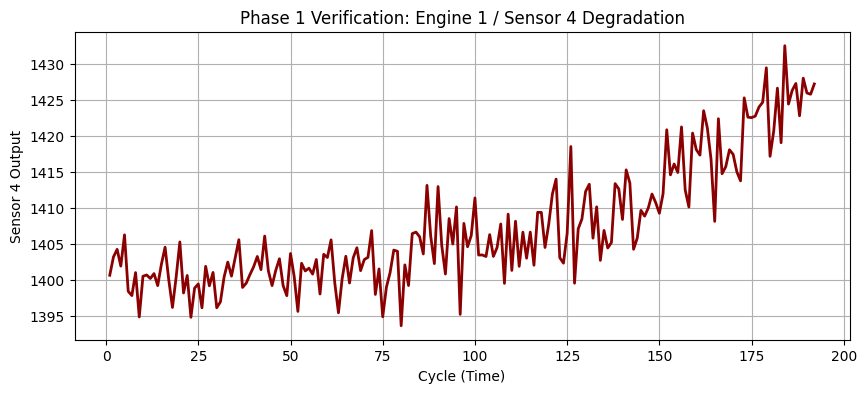

Shape   : (20631, 24)
Columns : ['Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3', 'Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16', 'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21']
Index   : ['Engine_ID', 'Cycle']



Op_Setting_1  Op_Setting_2  Op_Setting_3  Sensor_1  Sensor_2  \
Engine_ID Cycle                                                                 
1         1           -0.0007       -0.0004         100.0    518.67    641.82   
          2            0.0019       -0.0003         100.0    518.67    642.15   
          3           -0.0043        0.0003         100.0    518.67    642.35   

                 Sensor_3  Sensor_4  Sensor_5  Sensor_6  Sensor_7  ...  \
Engine_ID Cycle                                                    ...   
1         1       1589.70   1400.60     14.62     21.61    554.36  ...   
          2       1591.82   1403.14     14.62     21.61    553.75  ...   
          3       1587.99   1404.20     14.62     21.61    554.26  ...   

                 Sensor_12  Sensor_13  Sensor_14  Sensor_15  Sensor_16  \
Engine_ID Cycle                                                          
1         1         521.66    2388.02    8138.62     8.4195       0.03   
          2         522.28    2388.07    8131.49     8.4318       0.03   
          3         522.42    2388.03    8133.23     8.4178       0.03   

                 Sensor_17  Sensor_18  Sensor_19  Sensor_20  Sensor_21  
Engine_ID Cycle                                                         
1         1            392       2388      100.0      39.06    23.4190  
          2            392       2388      100.0      39.00    23.4236  
          3            390       2388      100.0      38.95    23.3442  

[3 rows x 24 columns]

In [2]:
with importnb.Notebook():
    import acquisition_and_profiling as phase_1

#Load the dataset
df_train = pd.read_csv(
    filepath_or_buffer= phase_1.os.path.join(phase_1.trainning_data_path, f"train_{phase_1.subset}.txt") ,
    sep=r'\s+',
    names=phase_1.columns,
    index_col=False
)

#Set Engine_id and Cycle as a composite PK
df_train.set_index(['Engine_ID', 'Cycle'], inplace=True)

print('Shape   :', df_train.shape)
print('Columns :', df_train.columns.tolist())
print('Index   :', df_train.index.names)
print()
df_train.head(3)

In [3]:
sensor_cols = [c for c in df_train.columns if c not in ['Engine_ID', 'Cycle', 'Op_Setting_1', 'Op_Setting_2', 'Op_Setting_3']]

stats = df_train[sensor_cols].agg(['mean', 'std', 'min', 'max']).T.round(4)
stats['is_constant'] = stats['std'] < 0.01

print(f'Total features  : {len(df_train.columns)}')
print(f'Sensor columns  : {len(sensor_cols)}')
print(f'Total rows      : {len(df_train)}')
print(f'Engines         : {df_train.index.get_level_values("Engine_ID").nunique()}')
print()
print('Per-sensor stats:')
print(stats.to_string())

Total features  : 24
Sensor columns  : 21
Total rows      : 20631
Engines         : 100

Per-sensor stats:
                mean      std        min        max  is_constant
Sensor_1    518.6700   0.0000   518.6700   518.6700         True
Sensor_2    642.6809   0.5001   641.2100   644.5300        False
Sensor_3   1590.5231   6.1311  1571.0400  1616.9100        False
Sensor_4   1408.9338   9.0006  1382.2500  1441.4900        False
Sensor_5     14.6200   0.0000    14.6200    14.6200         True
Sensor_6     21.6098   0.0014    21.6000    21.6100         True
Sensor_7    553.3677   0.8851   549.8500   556.0600        False
Sensor_8   2388.0967   0.0710  2387.9000  2388.5600        False
Sensor_9   9065.2429  22.0829  9021.7300  9244.5900        False
Sensor_10     1.3000   0.0000     1.3000     1.3000         True
Sensor_11    47.5412   0.2671    46.8500    48.5300        False
Sensor_12   521.4135   0.7376   518.6900   523.3800        False
Sensor_13  2388.0962   0.0719  2387.8800  2388.5

In [4]:
# Identify constant sensors from the stats we just printed
constant_sensors = stats[stats['is_constant']].index.tolist()
useful_sensors   = [s for s in sensor_cols if s not in constant_sensors]

print('Dropped (constant) :', constant_sensors)
print('Remaining sensors  :', useful_sensors)
print(f'\n{len(sensor_cols)} sensors -> {len(useful_sensors)} useful sensors')

# Drop them from the DataFrame
df_train_ = df_train.drop(columns=constant_sensors)

print('\nNew shape:', df_train_.shape)

Dropped (constant) : ['Sensor_1', 'Sensor_5', 'Sensor_6', 'Sensor_10', 'Sensor_16', 'Sensor_18', 'Sensor_19']
Remaining sensors  : ['Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_17', 'Sensor_20', 'Sensor_21']

21 sensors -> 14 useful sensors

New shape: (20631, 17)


In [5]:
# Calculate Maximum Lifespan (EOL) per Engine

engine_lifespans = df_train.groupby(level='Engine_ID').size()
engine_lifespans

# Extracting RUL

#Map The engine life span to the each Engine_ID
max_cycles_per_row = df_train.index.get_level_values('Engine_ID').map(engine_lifespans)
# max_cycles_per_row

#Calculate and add RUL
df_train['RUL'] = max_cycles_per_row - df_train.index.get_level_values('Cycle')
df_train

Op_Setting_1  Op_Setting_2  Op_Setting_3  Sensor_1  Sensor_2  \
Engine_ID Cycle                                                                 
1         1           -0.0007       -0.0004         100.0    518.67    641.82   
          2            0.0019       -0.0003         100.0    518.67    642.15   
          3           -0.0043        0.0003         100.0    518.67    642.35   
          4            0.0007        0.0000         100.0    518.67    642.35   
          5           -0.0019       -0.0002         100.0    518.67    642.37   
...                       ...           ...           ...       ...       ...   
100       196         -0.0004       -0.0003         100.0    518.67    643.49   
          197         -0.0016       -0.0005         100.0    518.67    643.54   
          198          0.0004        0.0000         100.0    518.67    643.42   
          199         -0.0011        0.0003         100.0    518.67    643.23   
          200         -0.0032       -0.0005         100.0    518.67    643.85   

                 Sensor_3  Sensor_4  Sensor_5  Sensor_6  Sensor_7  ...  \
Engine_ID Cycle                                                    ...   
1         1       1589.70   1400.60     14.62     21.61    554.36  ...   
          2       1591.82   1403.14     14.62     21.61    553.75  ...   
          3       1587.99   1404.20     14.62     21.61    554.26  ...   
          4       1582.79   1401.87     14.62     21.61    554.45  ...   
          5       1582.85   1406.22     14.62     21.61    554.00  ...   
...                   ...       ...       ...       ...       ...  ...   
100       196     1597.98   1428.63     14.62     21.61    551.43  ...   
          197     1604.50   1433.58     14.62     21.61    550.86  ...   
          198     1602.46   1428.18     14.62     21.61    550.94  ...   
          199     1605.26   1426.53     14.62     21.61    550.68  ...   
          200     1600.38   1432.14     14.62     21.61    550.79  ...   

                 Sensor_13  Sensor_14  Sensor_15  Sensor_16  Sensor_17  \
Engine_ID Cycle                                                          
1         1        2388.02    8138.62     8.4195       0.03        392   
          2        2388.07    8131.49     8.4318       0.03        392   
          3        2388.03    8133.23     8.4178       0.03        390   
          4        2388.08    8133.83     8.3682       0.03        392   
          5        2388.04    8133.80     8.4294       0.03        393   
...                    ...        ...        ...        ...        ...   
100       196      2388.26    8137.60     8.4956       0.03        397   
          197      2388.22    8136.50     8.5139       0.03        395   
          198      2388.24    8141.05     8.5646       0.03        398   
          199      2388.23    8139.29     8.5389       0.03        395   
          200      2388.26    8137.33     8.5036       0.03        396   

                 Sensor_18  Sensor_19  Sensor_20  Sensor_21  RUL  
Engine_ID Cycle                                                   
1         1           2388      100.0      39.06    23.4190  191  
          2           2388      100.0      39.00    23.4236  190  
          3           2388      100.0      38.95    23.3442  189  
          4           2388      100.0      38.88    23.3739  188  
          5           2388      100.0      38.90    23.4044  187  
...                    ...        ...        ...        ...  ...  
100       196         2388      100.0      38.49    22.9735    4  
          197         2388      100.0      38.30    23.1594    3  
          198         2388      100.0      38.44    22.9333    2  
          199         2388      100.0      38.29    23.0640    1  
          200         2388      100.0      38.37    23.0522    0  

[20631 rows x 25 columns]

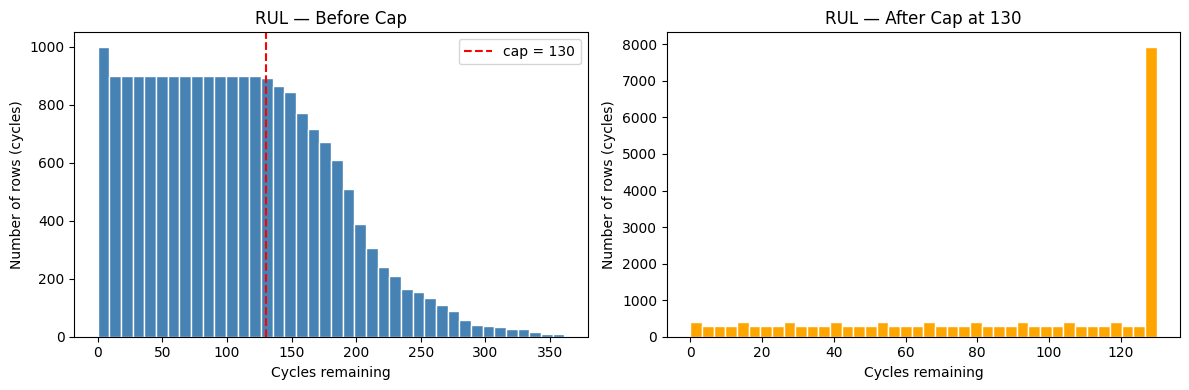

Max RUL after cap : 130
Min RUL           : 0


In [6]:
RUL_CAP = 130

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_train['RUL'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('RUL — Before Cap')
axes[0].set_xlabel('Cycles remaining')
axes[0].set_ylabel('Number of rows (cycles)')
axes[0].axvline(RUL_CAP, color='red', linestyle='--', label=f'cap = {RUL_CAP}')
axes[0].legend()

df_train_['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

axes[1].hist(df_train_['RUL'], bins=40, color='orange', edgecolor='white')
axes[1].set_title(f'RUL — After Cap at {RUL_CAP}')
axes[1].set_xlabel('Cycles remaining')
axes[1].set_ylabel('Number of rows (cycles)')

plt.tight_layout()
plt.show()

print(f'Max RUL after cap : {df_train_["RUL"].max()}')
print(f'Min RUL           : {df_train_["RUL"].min()}')

In [13]:
df_train['RUL'] = df_train['RUL'].clip(upper=RUL_CAP)

LAG_STEPS = [1, 2, 3]

for lag in LAG_STEPS:
    for col in useful_sensors:
        df_train[f'{col}_lag{lag}'] = (
            df_train.groupby(level='Engine_ID')[col]
            .shift(lag)
        )

lag_cols = [c for c in df_train.columns if '_lag' in c]

print(f'Lag columns added : {len(lag_cols)}')
print(f'Total columns now : {len(df_train.columns)}')
print(f'NaN rows introduced: {df_train[lag_cols].isna().any(axis=1).sum()}')
print()
# Show what the lag looks like for one engine and one sensor
sample = df_train.xs(1, level='Engine_ID')[['Sensor_9', 'Sensor_9_lag1', 'Sensor_9_lag2', 'Sensor_9_lag3']].head(6)
print('Example — Engine 1, sensor Sensor_9 with lags:')
print(sample.to_string())

Lag columns added : 42
Total columns now : 67
NaN rows introduced: 300

Example — Engine 1, sensor Sensor_9 with lags:
       Sensor_9  Sensor_9_lag1  Sensor_9_lag2  Sensor_9_lag3
Cycle                                                       
1       9046.19            NaN            NaN            NaN
2       9044.07        9046.19            NaN            NaN
3       9052.94        9044.07        9046.19            NaN
4       9049.48        9052.94        9044.07        9046.19
5       9055.15        9049.48        9052.94        9044.07
6       9049.68        9055.15        9049.48        9052.94


In [14]:
# Rolling statistics — capture trend, not just snapshot
for window in [5, 30]:                         # short + long window
    for col in useful_sensors:
        df_train[f'{col}_roll_mean{window}'] = df_train.groupby('Engine_ID')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df_train[f'{col}_roll_std{window}'] = df_train.groupby('Engine_ID')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0)
        )

roll_cols = [c for c in df_train.columns if '_roll_' in c]

print(f'Rolling columns added : {len(roll_cols)}')
print(f'Total columns now     : {len(df_train.columns)}')
print()
# Show what rolling looks like for one engine and one sensor
sample_window_5 = df_train.xs(1, level='Engine_ID')[['Sensor_9', 'Sensor_9_roll_mean5', 'Sensor_9_roll_std5']].head(8)
sample_window_30 = df_train.xs(1, level='Engine_ID')[['Sensor_9', 'Sensor_9_roll_mean30', 'Sensor_9_roll_std30']].head(8)
print('Example — Engine 1, sensor Sensor_9 with rolling window=5:')
print(sample_window_5.to_string())
print()
print('Example — Engine 1, sensor Sensor_9 with rolling window=30:')
print(sample_window_30.to_string())

Rolling columns added : 56
Total columns now     : 123

Example — Engine 1, sensor Sensor_9 with rolling window=5:
       Sensor_9  Sensor_9_roll_mean5  Sensor_9_roll_std5
Cycle                                                   
1       9046.19          9046.190000            0.000000
2       9044.07          9045.130000            1.499066
3       9052.94          9047.733333            4.632023
4       9049.48          9048.170000            3.881555
5       9055.15          9049.566000            4.587366
6       9049.68          9050.264000            4.193904
7       9059.13          9053.276000            4.038407
8       9040.80          9050.848000            6.915502

Example — Engine 1, sensor Sensor_9 with rolling window=30:
       Sensor_9  Sensor_9_roll_mean30  Sensor_9_roll_std30
Cycle                                                     
1       9046.19           9046.190000             0.000000
2       9044.07           9045.130000             1.499066
3       9052.94   

In [15]:
rows_before = len(df_train)

df = df_train.dropna()

rows_after   = len(df)
rows_dropped = rows_before - rows_after
engines      = df.index.get_level_values('Engine_ID').nunique()

print(f'Rows before : {rows_before}')
print(f'Rows dropped: {rows_dropped}  ({rows_dropped / rows_before * 100:.1f}%)')
print(f'Rows after  : {rows_after}')
print(f'Engines kept: {engines}')
print(f'NaN remaining: {df.isna().sum().sum()}')
print()
print('Final feature set:')
feature_cols = [c for c in df.columns if c not in ['RUL', 'Label_30']]
print(f'  {len(feature_cols)} features')
print(f'  {len(df)} samples')

Rows before : 20631
Rows dropped: 300  (1.5%)
Rows after  : 20331
Engines kept: 100
NaN remaining: 0

Final feature set:
  122 features
  20331 samples


In [16]:
engine_ids  = df.index.get_level_values('Engine_ID').unique()
split_point = int(len(engine_ids) * 0.8)

train_engines = engine_ids[:split_point]
test_engines  = engine_ids[split_point:]

train_df = df.loc[df.index.get_level_values('Engine_ID').isin(train_engines)]
test_df  = df.loc[df.index.get_level_values('Engine_ID').isin(test_engines)]

feature_cols = [c for c in df.columns if c not in ['Engine_ID','RUL']]

X_train, y_train = train_df[feature_cols].values, train_df['RUL'].values

X_test, y_test = test_df[feature_cols].values, test_df['RUL'].values

print(f'Train engines : {len(train_engines)}  (engine {train_engines[0]} to {train_engines[-1]})')
print(f'Test engines  : {len(test_engines)}  (engine {test_engines[0]} to {test_engines[-1]})')
print()
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

Train engines : 80  (engine 1 to 80)
Test engines  : 20  (engine 81 to 100)

X_train : (15898, 122)
X_test  : (4433, 122)
y_train : (15898,)
y_test  : (4433,)


In [17]:
N_ESTIMATORS = 100
MAX_DEPTH    = 15 # try 10 for faster training, or None for full depth (but risk overfitting)
MIN_SAMPLES_LEAF = 5
MAX_FEATURES = 'sqrt' # try 'log2' or a number like 10 for more/less features per tree
N_JOBS      = -1
RANDOM_STATE = 42
OOB_SCORE   = True

# Train
rf = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    max_features=MAX_FEATURES,
    oob_score=OOB_SCORE,       # free validation estimate during training
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
print('Training complete.')


print('Baseline performance on training set:')
# Evaluate
preds = rf.predict(X_train)
rmse  = root_mean_squared_error(y_train, preds) # target < 20
mse   = mean_squared_error(y_train, preds) # target < 400
mae   = mean_absolute_error(y_train, preds) # target < 10
r2    = r2_score(y_train, preds)
print(f"RMSE: {rmse:.2f} | MSE: {mse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")

print('Baseline performance on test set:')
# Evaluate
preds = rf.predict(X_test)
rmse  = root_mean_squared_error(y_test, preds) # target < 20
mse   = mean_squared_error(y_test, preds) # target < 400
mae   = mean_absolute_error(y_test, preds) # target < 10
r2    = r2_score(y_test, preds)
print(f"RMSE: {rmse:.2f} | MSE: {mse:.2f} | MAE: {mae:.2f} | R²: {r2:.3f}")

# Feature importance — which sensors matter most?

importances = pd.Series(rf.feature_importances_, index=feature_cols)
print(importances.sort_values(ascending=False).head(10))

Training complete.
Baseline performance on training set:
RMSE: 8.41 | MSE: 70.72 | MAE: 6.04 | R²: 0.963
Baseline performance on test set:
RMSE: 18.54 | MSE: 343.75 | MAE: 14.45 | R²: 0.816
Sensor_4_roll_mean5      0.089756
Sensor_15_roll_mean5     0.080344
Sensor_11_roll_mean5     0.079978
Sensor_3_roll_mean30     0.051645
Sensor_17_roll_mean5     0.046187
Sensor_20_roll_mean5     0.040649
Sensor_21_roll_mean5     0.039450
Sensor_17_roll_mean30    0.037255
Sensor_7_roll_mean5      0.031205
Sensor_21_roll_mean30    0.029662
dtype: float64


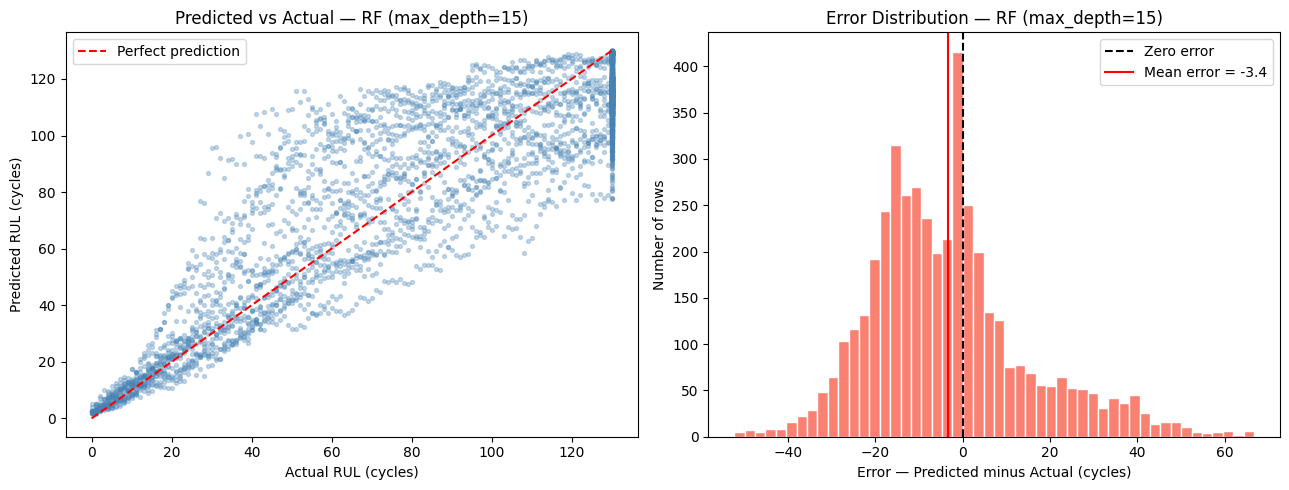

Mean error (bias) : -3.43 cycles
Std of errors     : 18.22 cycles

Positive mean -> model overestimates RUL (engine runs longer than expected)
Negative mean -> model underestimates RUL (engine pulled earlier than needed)


In [18]:
errors = preds - y_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Scatter: predicted vs actual ---
axes[0].scatter(y_test, preds, alpha=0.3, s=8, color='steelblue')
lim = max(y_test.max(), preds.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title(f'Predicted vs Actual — RF (max_depth={MAX_DEPTH})')
axes[0].legend()

# --- Error distribution ---
axes[1].hist(errors, bins=50, color='salmon', edgecolor='white')
axes[1].axvline(0,             color='black', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(errors.mean(), color='red',   linestyle='-',  linewidth=1.5, label=f'Mean error = {errors.mean():.1f}')
axes[1].set_xlabel('Error — Predicted minus Actual (cycles)')
axes[1].set_ylabel('Number of rows')
axes[1].set_title(f'Error Distribution — RF (max_depth={MAX_DEPTH})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Mean error (bias) : {errors.mean():+.2f} cycles')
print(f'Std of errors     : {errors.std():.2f} cycles')
print()
print('Positive mean -> model overestimates RUL (engine runs longer than expected)')
print('Negative mean -> model underestimates RUL (engine pulled earlier than needed)')

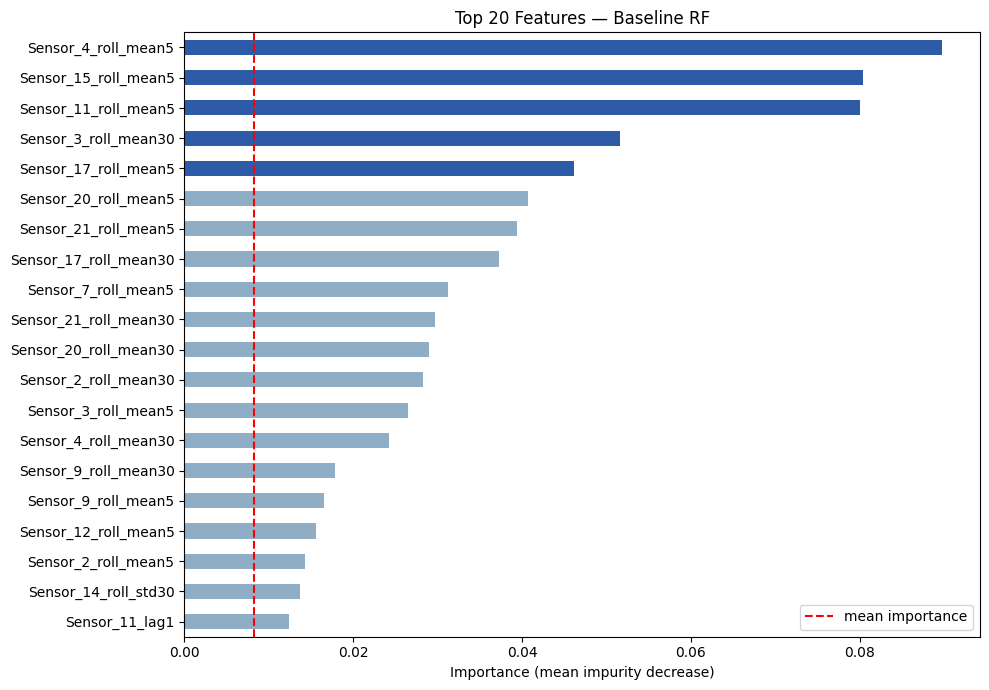

Top 10 features:
Sensor_4_roll_mean5      0.089756
Sensor_15_roll_mean5     0.080344
Sensor_11_roll_mean5     0.079978
Sensor_3_roll_mean30     0.051645
Sensor_17_roll_mean5     0.046187
Sensor_20_roll_mean5     0.040649
Sensor_21_roll_mean5     0.039450
Sensor_17_roll_mean30    0.037255
Sensor_7_roll_mean5      0.031205
Sensor_21_roll_mean30    0.029662

Bottom 5 features (least useful):
Sensor_5        0.0
Sensor_16       0.0
Sensor_19       0.0
Sensor_18       0.0
Op_Setting_3    0.0


In [19]:
feat_imp = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top_n = 20
top   = feat_imp.head(top_n).sort_values(ascending=True)

colors = ['#2E5BA8' if i >= top_n - 5 else '#90ADC6' for i in range(top_n)]

plt.figure(figsize=(10, 7))
top.plot(kind='barh', color=colors)
plt.axvline(feat_imp.mean(), color='red', linestyle='--', label='mean importance')
plt.title(f'Top {top_n} Features — Baseline RF')
plt.xlabel('Importance (mean impurity decrease)')
plt.legend()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(feat_imp.head(10).to_string())
print()
print('Bottom 5 features (least useful):')
print(feat_imp.tail(5).to_string())

In [20]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [6, 10, 14, 20],
    'max_features': ['sqrt', 'log2', 10],
}

grid = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = 3,
    scoring    = 'neg_root_mean_squared_error',
    verbose    = 1,
    n_jobs     = -1
)

grid.fit(X_train, y_train)

print(f'\nBest parameters : {grid.best_params_}')
print(f'Best CV RMSE    : {-grid.best_score_:.2f} cycles')

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters : {'max_depth': 14, 'max_features': 10, 'n_estimators': 200}
Best CV RMSE    : 17.89 cycles


RF on CMAPSS FD001 realistically plateaus around:

Metric	            Realistic ceiling
Test RMSE	        ~16–20 cycles
R²	                ~0.80–0.85
MAE	                ~12–16 cycles
That means predictions are off by ~18 cycles on average which is acceptable for long-horizon maintenance planning (scheduling a shop visit weeks out), but too coarse for precise "replace in exactly N cycles" decisions.

RF with good feature engineering can deliver RMSE ~16–18, enough to flag engines entering the danger zone and schedule maintenance windows. It will not reliably tell you "this engine has exactly 12 cycles left." For that level of precision, a sequence model is necessary.

Switch from RF to Gradient Boosting, push for XGBoost or LightGBM instead of RF:

Model	            || Expected RMSE
Random Forest	    || ~18–20
XGBoost / LightGBM	|| ~13–17
1D CNN / LSTM	    || ~10–14
